# Filter Atoms

Clean up extracted atoms using a second LLM pass.

Actions (in priority order):
1. **Keep** — Concrete, verifiable positional facts about the move
2. **Contextualize** — Not self-contained; rewrite with missing context so it stands alone (keep as separate atom)
3. **Move to alternative** — About a different move, not the played one
4. **Remove** — Generic labels only (no positional content)

In [45]:
import json
import math
import os
import random
import chess
import chess.svg
import openai
from IPython.display import display, SVG, Markdown, clear_output
from dotenv import load_dotenv

load_dotenv()

DIR = os.path.dirname(os.path.abspath('__file__'))
INPUT_PATH = os.path.join(DIR, 'included.jsonl')

with open(INPUT_PATH) as f:
    all_rows = [json.loads(line) for line in f]

print(f'Loaded {len(all_rows)} positions from {INPUT_PATH}')

total_atoms = sum(len(r['extracted'].get('reasoning', [])) for r in all_rows)
total_alt_atoms = sum(len(r['extracted'].get('alternative', {}).get('reasoning', [])) for r in all_rows)
print(f'Total atoms: {total_atoms} reasoning + {total_alt_atoms} alternative = {total_atoms + total_alt_atoms}')

client = openai.OpenAI()

K = 0.00368208  # Lichess win% formula constant

def parse_json(text):
    """Parse JSON from LLM output, stripping markdown code fences if present."""
    text = text.strip()
    if text.startswith('```'):
        text = text.split('\n', 1)[1]
        if text.endswith('```'):
            text = text[:-3]
        text = text.strip()
    return json.loads(text)


def cp_to_winpct(cp):
    return 50 + 50 * math.tanh(K * cp / 2)

Loaded 1302 positions from /Users/ashwin/Documents/Princeton/chess/chess_annotation/evaluation/data/logical_chess_atomize/included.jsonl
Total atoms: 3517 reasoning + 381 alternative = 3898


---
# Part 1 — Filter pass

Classify each reasoning atom as keep / contextualize / move_to_alternative / remove.

Full position context (FEN, engine lines, commentary, existing alternative) is
sent to the LLM. Only reasoning atoms are classified.

In [46]:
FILTER_MODEL = 'gpt-5.4'

FILTER_PROMPT = """\
You are filtering extracted reasoning atoms from chess commentary.

You will receive the FULL extracted JSON for a position (FEN, move played,
engine lines, original commentary, reasoning atoms, alternative section, etc.)

You have TWO jobs:
1. Classify each REASONING atom (keep / contextualize / move_to_alternative / remove)
2. Review each EXISTING ALTERNATIVE atom (keep / remove / paraphrase)

─── REASONING ATOMS ───

KEEP an atom if it states a concrete, verifiable positional fact about what
the move does: attacks, defends, controls, pins, blocks, develops, opens/
closes lines, creates threats, prevents opponent plans, explains why a move
is bad, etc.

CONTEXTUALIZE an atom that has useful content but is not self-contained on
its own. An atom is not self-contained if it references a consequence,
position, or piece without enough context to verify it independently.

Each atom stays SEPARATE — do NOT combine multiple atoms into one. Instead,
add the missing context so each atom is independently verifiable.
  Original: "On e4 the knight controls d6 and f6"
  Contextualized: "After Nd2, the knight on e4 would control d6 and f6."
Output: {"action": "contextualize", "new_text": "After Nd2, ..."}

IMPORTANT: Only add REFERENTIAL context — which move, which piece, which
square, which position. Do NOT add new chess claims, analysis, or
consequences that were not in the original atom. The goal is to make the
existing claim self-contained, not to enrich it.

MOVE_TO_ALTERNATIVE if the atom describes an ALTERNATIVE move (a move NOT
played) and its consequences.
  Output: {"action": "move_to_alternative", "move": "Bf4", "text": "..."}
  You may paraphrase the text so it reads naturally in the alternative section.

Conclusion vs. detailed analysis of alternatives:
- A CONCLUSION that the played move avoids or is better than an alternative
  is KEEP: "Qh4 avoids the inferior Qg5" -> KEEP.
- A DETAILED ANALYSIS of what happens after the alternative move is
  MOVE_TO_ALTERNATIVE: "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens
  Rd3" -> MOVE_TO_ALTERNATIVE for Qc1.
- When an atom MIXES both (conclusion + detailed line), SPLIT it using
  kept_brief:
  {"action": "move_to_alternative", "move": "Qc1",
   "text": "After 32.Qc1 Nxd4 33.Bxd4 Rxd4, Black threatens Rd3.",
   "kept_brief": "Qb2 avoids Qc1, which leads to dangerous threats on the d-file."}
  kept_brief stays in reasoning, text goes to the alternative.

DEDUPLICATION: Check the existing alternative section before adding. If an
alternative for that move already exists with equivalent content, do NOT add
duplicate text. You may instead paraphrase or remove the existing atom via
review_alternatives (see below).

REMOVE an atom ONLY if it is a generic label with no concrete positional
content. "Nbd2 is a typical Colle Attack manoeuvre." — naming an opening or
saying "typical/standard" without any positional claim is not a useful atom.

─── EXISTING ALTERNATIVE ATOMS ───

Review each atom in the existing alternative section(s). For each, choose:
- keep: leave as-is
- remove: delete (duplicate, or superseded by a moved reasoning atom)
- paraphrase: rewrite for clarity (provide new_text)

Output these in the "review_alternatives" array.

─── OUTPUT FORMAT ───

Output ONLY valid JSON:
{"atoms": [
  {"index": 0, "text": "...", "action": "keep"},
  {"index": 1, "text": "...", "action": "contextualize", "new_text": "..."},
  {"index": 2, "text": "...", "action": "move_to_alternative", "move": "Qc1",
   "text": "detailed line...", "kept_brief": "brief conclusion..."},
  {"index": 3, "text": "...", "action": "remove", "reason": "generic label"}
 ],
 "review_alternatives": [
  {"move": "Qc1", "index": 0, "action": "keep"},
  {"move": "Qc1", "index": 1, "action": "remove", "reason": "superseded"},
  {"move": "Bf4", "index": 0, "action": "paraphrase", "new_text": "..."}
 ]
}

review_alternatives uses the move name and 0-based index within that
alternative's reasoning array. Omit review_alternatives if there are no
existing alternatives.

Be conservative: when in doubt, KEEP. Prefer CONTEXTUALIZE over REMOVE when
an atom has useful content but just lacks context. Prefer MOVE_TO_ALTERNATIVE
over REMOVE when the atom is about a different move.
"""

print(f'Filter model: {FILTER_MODEL}')
print(f'Filter prompt: {len(FILTER_PROMPT)} chars')

Filter model: gpt-5.4
Filter prompt: 4247 chars


In [47]:
def filter_atoms(row, model=FILTER_MODEL):
    """Classify each reasoning atom as keep/remove/contextualize/move_to_alternative."""
    extracted = row['extracted']
    reasoning = extracted.get('reasoning', [])
    alt = extracted.get('alternative')  # single dict, list, or None

    all_atoms = [{'index': i, 'text': a} for i, a in enumerate(reasoning)]

    if not all_atoms:
        return {'atoms': [], 'filtered_reasoning': [],
                'alternatives': _normalize_alts(alt), 'new_alternatives': [],
                'review_alternatives': []}

    # Full context for the LLM
    context = {
        'fen': row['fen'],
        'move_uci': row['move_uci'],
        'move_san': row.get('move_san', ''),
        'annotation': row['annotation'],
        'quality': row.get('quality', ''),
        'wp_loss': row.get('wp_loss', 0),
        'engine_lines': [
            {'move_san': l['move_san'], 'eval': l['eval'],
             'pv_san': l['pv_san'], 'is_top': l.get('is_top', True)}
            for l in row.get('engine_lines', [])
        ],
        'reasoning': reasoning,
        'alternative': alt,
    }

    atoms_text = '\n'.join(f'{a["index"]}. "{a["text"]}"' for a in all_atoms)
    user_msg = (
        f'Position data:\n```json\n{json.dumps(context, indent=2)}\n```\n\n'
        f'Reasoning atoms to classify:\n{atoms_text}'
    )

    resp = client.chat.completions.create(
        model=model,
        messages=[
            {'role': 'system', 'content': FILTER_PROMPT},
            {'role': 'user', 'content': user_msg},
        ],
        temperature=0,
        max_completion_tokens=2048,
    )
    text = resp.choices[0].message.content.strip()

    try:
        result = parse_json(text)
    except json.JSONDecodeError:
        return {'atoms': [], 'error': 'JSON parse error', 'raw': text,
                'filtered_reasoning': reasoning,
                'alternatives': _normalize_alts(alt), 'new_alternatives': [],
                'review_alternatives': []}

    if 'atoms' not in result:
        return {'atoms': [], 'error': 'no atoms key',
                'filtered_reasoning': reasoning,
                'alternatives': _normalize_alts(alt), 'new_alternatives': [],
                'review_alternatives': []}

    # Parse reasoning atom actions
    atoms_by_idx = {a['index']: a for a in result['atoms']}
    moved_to_alt = []

    for a in result['atoms']:
        if a.get('action') == 'move_to_alternative':
            moved_to_alt.append({
                'move': a.get('move', '?'),
                'text': a.get('text', ''),
            })

    # Build filtered reasoning
    filtered_reasoning = []
    for atom_info in all_atoms:
        idx = atom_info['index']
        a = atoms_by_idx.get(idx, {})
        action = a.get('action', 'keep')

        if action == 'remove':
            continue
        if action == 'move_to_alternative':
            # If kept_brief provided, add that to reasoning instead
            if a.get('kept_brief'):
                filtered_reasoning.append(a['kept_brief'])
            continue
        if action == 'contextualize' and a.get('new_text'):
            filtered_reasoning.append(a['new_text'])
        else:
            filtered_reasoning.append(atom_info['text'])

    # Apply review_alternatives to existing alternatives
    alternatives = _normalize_alts(alt)
    review_alts = result.get('review_alternatives', [])

    # Index reviews by (move, index)
    alt_reviews = {}
    for ra in review_alts:
        key = (ra.get('move', ''), ra.get('index', 0))
        alt_reviews[key] = ra

    for a in alternatives:
        move_name = a['move']
        old_reasoning = a.get('reasoning', [])
        new_reasoning = []
        for i, atom_text in enumerate(old_reasoning):
            ra = alt_reviews.get((move_name, i))
            if ra:
                action = ra.get('action', 'keep')
                if action == 'remove':
                    continue
                elif action == 'paraphrase' and ra.get('new_text'):
                    new_reasoning.append(ra['new_text'])
                else:
                    new_reasoning.append(atom_text)
            else:
                new_reasoning.append(atom_text)
        a['reasoning'] = new_reasoning

    # Add moved atoms to alternatives — match existing by move name, or create new
    for ma in moved_to_alt:
        move_name = ma['move']
        existing = next((a for a in alternatives if a['move'] == move_name), None)
        if existing:
            existing['reasoning'].append(ma['text'])
        else:
            alternatives.append({'move': move_name, 'reasoning': [ma['text']]})

    # Remove alternatives that ended up with 0 reasoning atoms
    alternatives = [a for a in alternatives if a.get('reasoning')]

    return {
        'atoms': result['atoms'],
        'filtered_reasoning': filtered_reasoning,
        'alternatives': alternatives,
        'new_alternatives': moved_to_alt,
        'review_alternatives': review_alts,
    }


def _normalize_alts(alt):
    """Normalize alternative field to a list of {move, reasoning, ...} dicts."""
    if not alt:
        return []
    if isinstance(alt, list):
        return [dict(a) for a in alt]
    return [dict(alt)]


def _alt_quality(alt_move_san, engine_lines):
    """Compute quality label for an alternative move from engine lines."""
    top_lines = [l for l in engine_lines if l.get('is_top', True)]
    if not top_lines:
        return None
    best = top_lines[0]
    alt_line = next((l for l in engine_lines if l['move_san'] == alt_move_san), None)
    if alt_line is None:
        return None
    best_wp = cp_to_winpct(best['cp'])
    alt_wp = cp_to_winpct(alt_line['cp'])
    loss = abs(best_wp - alt_wp)
    if loss > 30:
        return 'blunder'
    elif loss > 20:
        return 'mistake'
    elif loss > 10:
        return 'inaccuracy'
    return 'good'


def run_filter(row, model=FILTER_MODEL):
    """Run filter and build the output row with quality-labeled alternatives."""
    result = filter_atoms(row, model=model)

    out_row = dict(row)
    filtered_extracted = dict(row['extracted'])
    filtered_extracted['reasoning'] = result['filtered_reasoning']
    alts = result['alternatives']
    filtered_extracted['alternative'] = alts[0] if len(alts) == 1 else (alts or None)
    out_row['extracted'] = filtered_extracted

    # Post-process: add quality to alternatives
    engine_lines = row.get('engine_lines', [])
    alt_field = filtered_extracted.get('alternative')
    if alt_field and engine_lines:
        alt_list = alt_field if isinstance(alt_field, list) else [alt_field]
        for a in alt_list:
            if 'quality' not in a and a.get('move'):
                q = _alt_quality(a['move'], engine_lines)
                if q:
                    a['quality'] = q

    return result, out_row


print('filter_atoms, run_filter ready')

filter_atoms, run_filter ready


### Filter sample: 20 positions

In [51]:
SEED = 45
N_SAMPLE = 20

rng = random.Random(SEED)
review_order = list(range(len(all_rows)))
rng.shuffle(review_order)

sample_rows = [all_rows[i] for i in review_order[:N_SAMPLE]]

sample_results = []
for i, row in enumerate(sample_rows):
    board = chess.Board(row['fen'])
    san = board.san(chess.Move.from_uci(row['move_uci']))
    print(f'[{i+1}/{N_SAMPLE}] {row["game"]} — {san}')
    result, out_row = run_filter(row)
    sample_results.append((row, result, out_row))

print(f'\nDone. {N_SAMPLE} positions filtered.')

[1/20] Blackburne – Blanchard — d4
[2/20] Tarrasch – Mieses — Ra5
[3/20] Rubinstein – Maroczy — Re8
[4/20] Pitschak – Flohr — Nf6
[5/20] Tarrasch – Mieses — Bd7
[6/20] Vliet – Znosko-Borovsky — Kd2
[7/20] Blackburne – Blanchard — Nc3
[8/20] Spielmann – Wahle — O-O
[9/20] Rubinstein – Salwe — Bg2
[10/20] Tarrasch – Mieses — Re1
[11/20] Bernstein – Mieses — Bc5
[12/20] Chekhover – Rudakowsky — Rd6
[13/20] Capablanca – Mattison — O-O
[14/20] Marshall – Tarrasch — Be3
[15/20] Canal – Capablanca — Qb6
[16/20] Scheve – Teichmann — Nxe5
[17/20] Tarrasch – Mieses — Nd5
[18/20] Znosko-Borovsky – Mackenzie — Qh4
[19/20] Havasi – Capablanca — b4
[20/20] Spielmann – Wahle — c6

Done. 20 positions filtered.


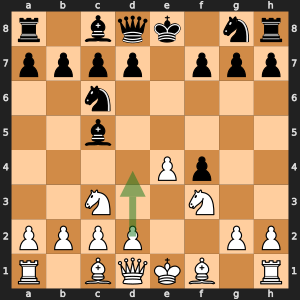

### [1/20] Blackburne – Blanchard — White plays d4 (good, wp_loss=3.8%)

> Of course! No player should take more than half a second to see the power of this pawn push! The pawn seizes control of a good bit of the centre (occupying d4 and attacking two other important squares), dislodges the bishop from its strong position, and uncovers an attack by his own c1-bishop on the f4-pawn.

#### Atom decisions
✅ d4 occupies d4 and attacks the important squares c5 and e5.

✅ d4 attacks the bishop on c5 and drives it from its strong position.

✅ d4 opens the diagonal of White's bishop on c1 toward f4, uncovering an attack on the pawn on f4.

#### Resulting reasoning
1. d4 occupies d4 and attacks the important squares c5 and e5.
2. d4 attacks the bishop on c5 and drives it from its strong position.
3. d4 opens the diagonal of White's bishop on c1 toward f4, uncovering an attack on the pawn on f4.

**3 → 3 reasoning atoms**

---

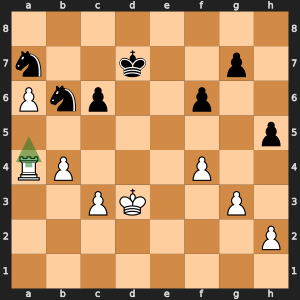

### [2/20] Tarrasch – Mieses — White plays Ra5 (good, wp_loss=0.0%)

> The rook leaves but loses no time, as it threatens to capture Black’s h-pawn.

#### Atom decisions
✅ Ra5 moves the rook away while still threatening to capture the h5-pawn.

#### Resulting reasoning
1. Ra5 moves the rook away while still threatening to capture the h5-pawn.

**1 → 1 reasoning atoms**

---

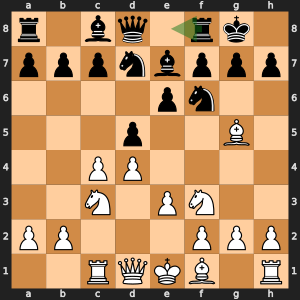

### [3/20] Rubinstein – Maroczy — Black plays Re8 (good, wp_loss=1.6%)

> Black’s rook moves to a centre file, where it may play a useful part in any action that takes place in the centre. The rook’s presence on the file is of little consequence now, but with every clearance on the file, its influence grows stronger and stronger.
Black’s game is cramped, but alternatives aimed at freeing it immediately are not convincing:
1) 7...dxc4 8 Bxc4 and White gains a tempo with this bishop, since it recaptures and develops at the same time.
2) 7... a6 (in order to continue with 8...dxc4 9 Bxc4 b5 10 Bd3 Bb7) 8 c5 can be very constraining.
3) 7... c5 8 dxc5 Nxc5 9 cxd5 exd5 (not9... Nxd5 10 Nxd5 exd5 11 Rxc5! Bxg5 12 Rxd5, when White wins the bishop) and Black’s d5-pawn is weak, while White has the fine d4-square as a central point for manoeuvring his pieces to any part of the board.

#### Atom decisions
✅ Re8 places the rook on a central file, where it can support future action in the center.

✅ Although the rook's presence on the e-file has little immediate effect, its influence increases as the file is cleared.

#### Alternative atom reviews
✅ dxc4[0]: keep

#### Resulting reasoning
1. Re8 places the rook on a central file, where it can support future action in the center.
2. Although the rook's presence on the e-file has little immediate effect, its influence increases as the file is cleared.

#### Alternatives

**dxc4**:
  - After 7...dxc4 8.Bxc4, White recaptures while developing the bishop, gaining a tempo.


**2 → 2 reasoning atoms**

---

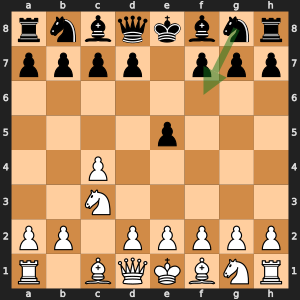

### [4/20] Pitschak – Flohr — Black plays Nf6 (good, wp_loss=0.3%)

> Black watches the order of his moves. The knight move is not merely routine development of a piece. Its purpose is to offset the pressure of White’s knight and pawn on the d5-square.

#### Atom decisions
❌ Nf6 is not played as routine development alone. — *generic commentary without concrete positional content*

✅ Nf6 is intended to offset the pressure that White's knight and pawn exert on the d5-square.

#### Resulting reasoning
1. Nf6 is intended to offset the pressure that White's knight and pawn exert on the d5-square.

**2 → 1 reasoning atoms (1 removed)**

---

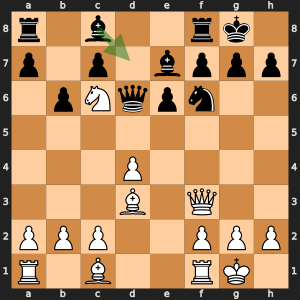

### [5/20] Tarrasch – Mieses — Black plays Bd7 (good, wp_loss=0.0%)

> The upshot of all this is that in order to save the rook’s life the bishop must be content to move to d7, where it has little scope.

#### Atom decisions
✅ To save the rook, the bishop must move to d7.

✅ After Bd7, the bishop on d7 has little scope.

#### Resulting reasoning
1. To save the rook, the bishop must move to d7.
2. After Bd7, the bishop on d7 has little scope.

**2 → 2 reasoning atoms**

---

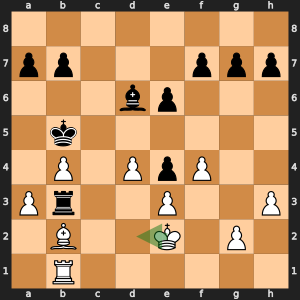

### [6/20] Vliet – Znosko-Borovsky — White plays Kd2 (good, wp_loss=0.0%)

> White’s rook and bishop are immobilized, so he is reduced to king moves and not too many at that, as the e-pawn needs protection.

#### Atom decisions
✅ White's rook and bishop are immobilized.

✅ Because the e3-pawn needs protection, White is reduced mainly to king moves.

#### Resulting reasoning
1. White's rook and bishop are immobilized.
2. Because the e3-pawn needs protection, White is reduced mainly to king moves.

**2 → 2 reasoning atoms**

---

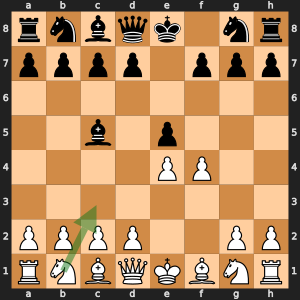

### [7/20] Blackburne – Blanchard — White plays Nc3 (good, wp_loss=1.7%)

> White avoids 3 fxe5 because the reply (coming like a shot, probably) 3... Qh4+ 4 g3 (even worse is 4 Ke2 Qxe4#) 4... Qxe4+ wins a rook for Black.
White’s actual move is not as energetic as 3 Nf3, but in playing 3 Nc3 Blackburne was trying to lure his opponent into playing 3.... B xgl 4 R xgl Qh4+ 5 g3 Qxh2, when 6 Rg2 followed by 7 fxe5 gives White a fine game.

#### Atom decisions
➡️ After 3.fxe5 Qh4+ 4.g3, Black has 4...Qxe4+, winning a rook. → *alternative (fxe5)*

  → kept brief: **Nc3 avoids 3.fxe5 because Black can exploit the exposed king and win material.**

➡️ After 3.fxe5 Qh4+ 4.Ke2, Black mates with 4...Qxe4#. → *alternative (fxe5)*

  → kept brief: **Nc3 avoids 3.fxe5 because Black has a mating attack if White responds inaccurately.**

✅ Nc3 is less energetic than Nf3.

✅ Nc3 tries to lure Black into 3...Bxg1 4.Rxg1 Qh4+ 5.g3 Qxh2, when 6.Rg2 followed by 7.fxe5 gives White a fine game.

#### Alternative atom reviews
✅ Nf3[0]: keep

#### Resulting reasoning
1. Nc3 avoids 3.fxe5 because Black can exploit the exposed king and win material.
2. Nc3 avoids 3.fxe5 because Black has a mating attack if White responds inaccurately.
3. Nc3 is less energetic than Nf3.
4. Nc3 tries to lure Black into 3...Bxg1 4.Rxg1 Qh4+ 5.g3 Qxh2, when 6.Rg2 followed by 7.fxe5 gives White a fine game.

#### Alternatives

**Nf3** (good):
  - Nf3 is more energetic than Nc3.

**fxe5**:
  - After 3.fxe5 Qh4+ 4.g3, Black has 4...Qxe4+, winning a rook.
  - After 3.fxe5 Qh4+ 4.Ke2, Black mates with 4...Qxe4#.


**4 → 4 reasoning atoms (2 → alternative, 2 kept brief)**

---

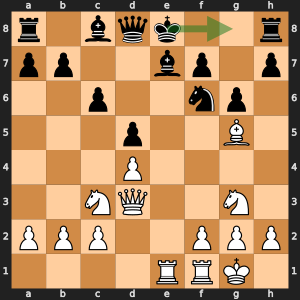

### [8/20] Spielmann – Wahle — Black plays O-O (good, wp_loss=4.4%)

> The king takes refuge in flight, incidentally unpinning the bishop and preserving his knight.
Spielmann’s strategy to this point and the decisive combination that follows would have pleased Lasker, who once said, “In the beginning of the game ignore the search for combinations, abstain from violent moves. Aim for small advantages, accumulate them, and only after having attained these ends search for the combination – and then with all the power of will and intellect, because then the combination must exist, however deeply hidden.”
A glance shows that White has achieved the requisite positional superiority. If there is a combination to be evolved, it must be now, before Black has time to reorganize his pieces for defence. Now, while he has five pieces actively in play against two of Black’s. Now, while he has an open file – enough! enough! The combination must be there!
Here is White’s line of reasoning:
Black’s advance of the g-pawn has deprived the knight of stable support. It is still guarded by two pieces, but if the bishop were not there it would be defended only once. In fact, if the bishop were not there, the knight would be pinned and subject to an enduring attack. The bishop appears in both equations. Obviously the bishop is the culprit, and it must be destroyed! And at once, before Black has time for 12... Be6!

#### Atom decisions
✅ O-O moves the king to safety.

✅ O-O unpins the bishop.

🔄 O-O preserves Black's knight.

  → **By castling with O-O, Black preserves the knight on f6.**

#### Resulting reasoning
1. O-O moves the king to safety.
2. O-O unpins the bishop.
3. By castling with O-O, Black preserves the knight on f6.

**3 → 3 reasoning atoms (1 contextualized)**

---

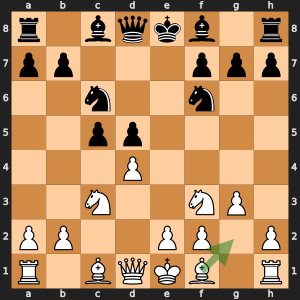

### [9/20] Rubinstein – Salwe — White plays Bg2 (good, wp_loss=0.0%)

> The bishop commands the long diagonal and will devote special attention to Black’s d-pawn. For the moment, the knight obstructs its path, but a knight can readily leap aside.

#### Atom decisions
✅ Bg2 places the bishop on the long diagonal.

✅ Bg2 aims the bishop at Black's d5-pawn.

🔄 Although the knight currently obstructs the bishop's line, the knight can readily move aside to open the diagonal.

  → **After Bg2, White's knight on f3 currently obstructs the bishop's line on the long diagonal, but the knight can readily move aside to open the diagonal.**

#### Resulting reasoning
1. Bg2 places the bishop on the long diagonal.
2. Bg2 aims the bishop at Black's d5-pawn.
3. After Bg2, White's knight on f3 currently obstructs the bishop's line on the long diagonal, but the knight can readily move aside to open the diagonal.

**3 → 3 reasoning atoms (1 contextualized)**

---

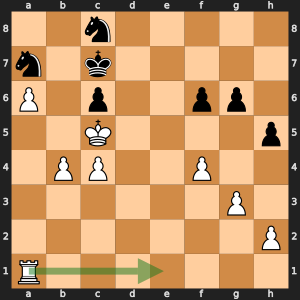

### [10/20] Tarrasch – Mieses — White plays Re1 (good, wp_loss=0.0%)

> Poised for invasion at e6 or e8 and a raid on the kingside pawns.

#### Atom decisions
✅ Re1 prepares a rook invasion to e6 or e8.

🔄 After entering on the e-file, the rook can attack Black's kingside pawns.

  → **After Re1, if the rook enters on e6 or e8 via the e-file, it can attack Black's kingside pawns.**

#### Resulting reasoning
1. Re1 prepares a rook invasion to e6 or e8.
2. After Re1, if the rook enters on e6 or e8 via the e-file, it can attack Black's kingside pawns.

**2 → 2 reasoning atoms (1 contextualized)**

---

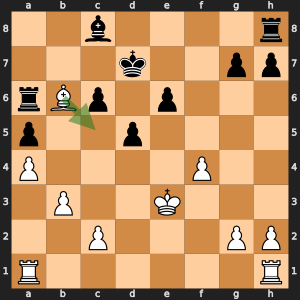

### [11/20] Bernstein – Mieses — White plays Bc5 (good, wp_loss=0.0%)

> White dominates every important square on the board! The bishop stops the h8-rook from getting to f8, the a6-rook from moving to b6, the king from d6, the d-pawn from advancing and the c-pawn from moving at all! Compare its control of eight squares with that of Black’s bishop, whose influence is confined to one square! This difference in their potential accounts in great measure for the extent of White’s attacking opportunities, and for the consequent difficulty Black will have in defending. Every gain or control of territory by White will result in more and more cramping of Black’s position.

#### Atom decisions
✅ Bc5 dominates key squares in Black's position.

✅ After Bc5, the bishop prevents the rook on h8 from reaching f8.

✅ After Bc5, the bishop prevents the rook on a6 from moving to b6.

✅ After Bc5, the bishop controls d6 and keeps the black king out of that square.

✅ After Bc5, the bishop stops the d5-pawn from advancing.

✅ After Bc5, the bishop stops the c6-pawn from moving.

✅ The bishop on c5 controls eight squares, while Black's bishop has influence over only one square.

✅ White's greater piece activity after Bc5 gives him stronger attacking chances and makes Black's defense difficult.

✅ After Bc5, any further territorial gain by White will cramp Black's position even more.

#### Resulting reasoning
1. Bc5 dominates key squares in Black's position.
2. After Bc5, the bishop prevents the rook on h8 from reaching f8.
3. After Bc5, the bishop prevents the rook on a6 from moving to b6.
4. After Bc5, the bishop controls d6 and keeps the black king out of that square.
5. After Bc5, the bishop stops the d5-pawn from advancing.
6. After Bc5, the bishop stops the c6-pawn from moving.
7. The bishop on c5 controls eight squares, while Black's bishop has influence over only one square.
8. White's greater piece activity after Bc5 gives him stronger attacking chances and makes Black's defense difficult.
9. After Bc5, any further territorial gain by White will cramp Black's position even more.

**9 → 9 reasoning atoms**

---

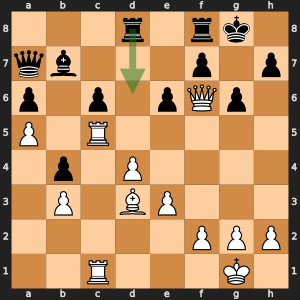

### [12/20] Chekhover – Rudakowsky — Black plays Rd6 (good, wp_loss=0.6%)

> Black vacates d8, so that his queen can return to that square and challenge White’s. In chess language: if 29 h4 Qa8 30 h5 Qd8, White’s queen must leave f6 and forego the threat of mate.

#### Atom decisions
✅ Rd6 vacates d8 for the queen.

✅ After 28...Rd6 29.h4 Qa8 30.h5 Qd8, Black's queen reaches d8 to challenge White's queen on f6.

✅ After 28...Rd6 29.h4 Qa8 30.h5 Qd8, White's queen must leave f6 and the mating threat disappears.

#### Resulting reasoning
1. Rd6 vacates d8 for the queen.
2. After 28...Rd6 29.h4 Qa8 30.h5 Qd8, Black's queen reaches d8 to challenge White's queen on f6.
3. After 28...Rd6 29.h4 Qa8 30.h5 Qd8, White's queen must leave f6 and the mating threat disappears.

**3 → 3 reasoning atoms**

---

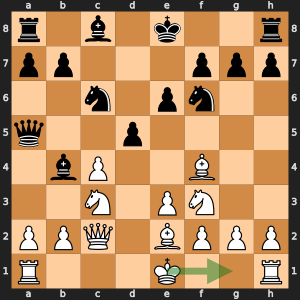

### [13/20] Capablanca – Mattison — White plays O-O (good, wp_loss=0.0%)

> The king is made secure, while the h 1-rook moves closer to the centre, the theatre of action. The rook, of course, will try to seize an open file, or, if none is available, one which is likely to be opened.

#### Atom decisions
✅ O-O makes the king secure on the kingside.

✅ O-O brings the rook from h1 closer to the centre, where the main action is likely to occur.

✅ After O-O, the rook can aim to occupy an open file or a file likely to be opened.

#### Resulting reasoning
1. O-O makes the king secure on the kingside.
2. O-O brings the rook from h1 closer to the centre, where the main action is likely to occur.
3. After O-O, the rook can aim to occupy an open file or a file likely to be opened.

**3 → 3 reasoning atoms**

---

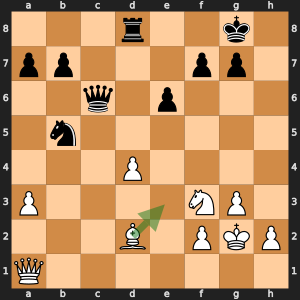

### [14/20] Marshall – Tarrasch — White plays Be3 (good, wp_loss=0.0%)

> Guarding the d-pawn, since the pinned knight is no protection.

#### Atom decisions
✅ Be3 guards the pawn on d4.

🔄 The knight that appears to defend d4 is pinned and therefore cannot be relied on as protection.

  → **The white knight on f3 that appears to defend d4 is pinned and therefore cannot be relied on as protection.**

#### Resulting reasoning
1. Be3 guards the pawn on d4.
2. The white knight on f3 that appears to defend d4 is pinned and therefore cannot be relied on as protection.

**2 → 2 reasoning atoms (1 contextualized)**

---

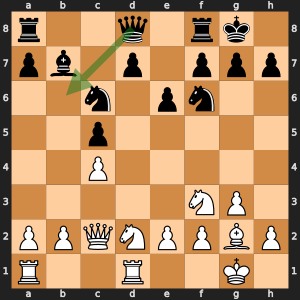

### [15/20] Canal – Capablanca — Black plays Qb6 (good, wp_loss=1.3%)

> Now there are three pieces bearing down on d4, while the queen herself gets a purchase on the open b-file.

#### Atom decisions
✅ Qb6 increases Black's pressure on d4 so that three black pieces bear down on that square.

✅ Qb6 places the queen on the open b-file.

#### Resulting reasoning
1. Qb6 increases Black's pressure on d4 so that three black pieces bear down on that square.
2. Qb6 places the queen on the open b-file.

**2 → 2 reasoning atoms**

---

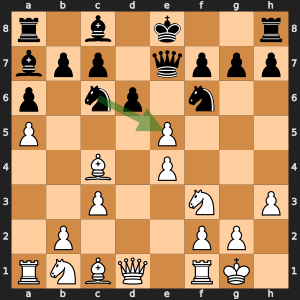

### [16/20] Scheve – Teichmann — Black plays Nxe5 (good, wp_loss=0.0%)

> Much stronger than taking with the pawn. The knight on e5, beautifully centralized, radiates power in every direction (something a pawn cannot do).
The disappearance of White’s d-pawn has benefited Black’s bishop, hidden away at a7. Its range has been extended, so that it now controls the whole of the long diagonal leading to White’s f2-pawn – and the king is just behind the pawn!
What shall White do now? He has done nothing to relieve the plight of his e-pawn – it is still attacked by one of Black’s knights, while his bishop is threatened by the other.

#### Atom decisions
✅ Nxe5 is stronger than recapturing with the pawn because the knight on e5 becomes a centralized piece that influences many squares.

✅ After Nxe5, White's d-pawn has disappeared, which opens the long diagonal a7-g1 for Black's bishop on a7 toward the f2-pawn and the king behind it.

🔄 After Nxe5, White's e-pawn remains under attack by one black knight while White's bishop is threatened by the other.

  → **After Nxe5, White's e5-pawn remains under attack by Black's knight on f7? while White's bishop on c4 is threatened by Black's other knight.**

#### Alternative atom reviews
✅ dxe5[0]: keep

#### Resulting reasoning
1. Nxe5 is stronger than recapturing with the pawn because the knight on e5 becomes a centralized piece that influences many squares.
2. After Nxe5, White's d-pawn has disappeared, which opens the long diagonal a7-g1 for Black's bishop on a7 toward the f2-pawn and the king behind it.
3. After Nxe5, White's e5-pawn remains under attack by Black's knight on f7? while White's bishop on c4 is threatened by Black's other knight.

#### Alternatives

**dxe5** (good):
  - Taking with the pawn is weaker because a pawn on e5 does not provide the same centralized activity as a knight on e5.


**3 → 3 reasoning atoms (1 contextualized)**

---

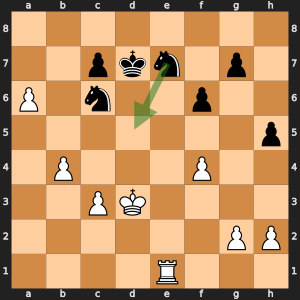

### [17/20] Tarrasch – Mieses — Black plays Nd5 (good, wp_loss=0.0%)

> The knight is on its way to the queenside. Meanwhile it attacks the loose f-pawn.

#### Atom decisions
✅ Nd5 reroutes the knight toward the queenside.

✅ Nd5 attacks the loose pawn on f4.

#### Resulting reasoning
1. Nd5 reroutes the knight toward the queenside.
2. Nd5 attacks the loose pawn on f4.

**2 → 2 reasoning atoms**

---

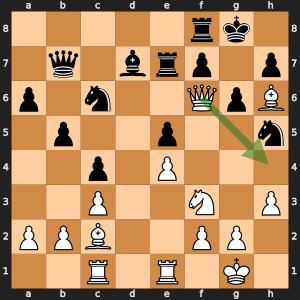

### [18/20] Znosko-Borovsky – Mackenzie — White plays Qh4 (good, wp_loss=0.0%)

> It would be a mistake to play 23 Qg5 as Black, instead of moving his threatened rook on f8, would first play 23... f6, banishing the queen completely from his premises.

#### Atom decisions
✅ Qh4 avoids the inferior 23.Qg5.

➡️ After 23.Qg5, Black can play 23...f6 before moving the threatened rook on f8, driving the queen away. → *alternative (Qg5)*

  → kept brief: **Qh4 avoids 23.Qg5, when Black can respond actively with ...f6.**

#### Alternative atom reviews
✅ Qg5[0]: keep

🔄 Qg5[1] → **After 23.Qg5 f6, Black drives the white queen away from the kingside.**

#### Resulting reasoning
1. Qh4 avoids the inferior 23.Qg5.
2. Qh4 avoids 23.Qg5, when Black can respond actively with ...f6.

#### Alternatives

**Qg5** (good):
  - After 23.Qg5, Black does not need to move the threatened rook on f8 immediately.
  - After 23.Qg5 f6, Black drives the white queen away from the kingside.
  - After 23.Qg5, Black can play 23...f6 before moving the threatened rook on f8, driving the queen away.


**2 → 2 reasoning atoms (1 → alternative, 1 kept brief)**

---

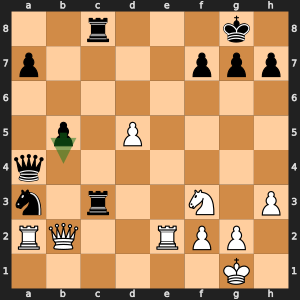

### [19/20] Havasi – Capablanca — Black plays b4 (good, wp_loss=0.0%)

> An obvious move, but brilliant nevertheless in the number of things it accomplishes:
1) it nullifies White’s threat, the e8-square now being covered by the queen;
2) it defends the knight, freeing the queen from that duty;
3) it advances the pawn one step nearer its ultimate goal, the eighth rank.

#### Atom decisions
🔄 b4 covers the e8-square with the queen, nullifying White's threat.

  → **After ...b4, Black's queen covers e8, nullifying White's threat on that square.**

✅ b4 defends the knight on a3, so the queen no longer has to protect it.

✅ b4 advances the b-pawn one step closer to promotion on the eighth rank.

#### Resulting reasoning
1. After ...b4, Black's queen covers e8, nullifying White's threat on that square.
2. b4 defends the knight on a3, so the queen no longer has to protect it.
3. b4 advances the b-pawn one step closer to promotion on the eighth rank.

**3 → 3 reasoning atoms (1 contextualized)**

---

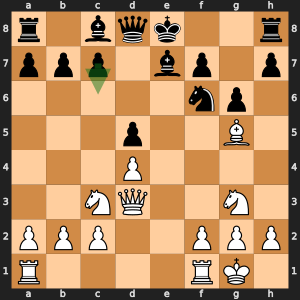

### [20/20] Spielmann – Wahle — Black plays c6 (good, wp_loss=4.5%)

> Strengthens Black’s pawn-centre and opens another avenue for his queen.

#### Atom decisions
✅ c6 strengthens Black's pawn center.

✅ c6 opens another line for Black's queen.

#### Resulting reasoning
1. c6 strengthens Black's pawn center.
2. c6 opens another line for Black's queen.

**2 → 2 reasoning atoms**

---

In [52]:
for idx, (row, result, out_row) in enumerate(sample_results):
    board = chess.Board(row['fen'])
    move = chess.Move.from_uci(row['move_uci'])
    move_san = board.san(move)
    is_bad = row['quality'] in ('inaccuracy', 'mistake', 'blunder')
    arrow_color = '#cc0000' if is_bad else '#15781B'

    svg = chess.svg.board(
        board,
        arrows=[(move.from_square, move.to_square)],
        colors={'arrow': arrow_color},
        size=300,
    )
    display(SVG(svg))

    turn = 'White' if board.turn == chess.WHITE else 'Black'
    display(Markdown(
        f'### [{idx+1}/{len(sample_results)}] {row["game"]} — '
        f'{turn} plays {move_san} ({row["quality"]}, wp_loss={row["wp_loss"]:.1f}%)'
    ))

    display(Markdown(f'> {row["annotation"]}'))

    # Show LLM decisions per reasoning atom
    atoms = result.get('atoms', [])
    if atoms:
        lines = []
        for a in atoms:
            action = a.get('action', 'keep')
            if action == 'keep':
                lines.append(f'\u2705 {a["text"]}')
            elif action == 'remove':
                reason = f' — *{a["reason"]}*' if a.get('reason') else ''
                lines.append(f'\u274c {a["text"]}{reason}')
            elif action == 'move_to_alternative':
                alt_move = a.get('move', '?')
                lines.append(f'\u27a1\ufe0f {a["text"]} \u2192 *alternative ({alt_move})*')
                if a.get('kept_brief'):
                    lines.append(f'  \u2192 kept brief: **{a["kept_brief"]}**')
            elif action == 'contextualize':
                lines.append(f'\U0001f504 {a["text"]}')
                if a.get('new_text'):
                    lines.append(f'  \u2192 **{a["new_text"]}**')
        display(Markdown('#### Atom decisions\n' + '\n\n'.join(lines)))

    # Show LLM decisions on existing alternative atoms
    review_alts = result.get('review_alternatives', [])
    if review_alts:
        ra_lines = []
        for ra in review_alts:
            action = ra.get('action', 'keep')
            move_name = ra.get('move', '?')
            ri = ra.get('index', 0)
            if action == 'keep':
                ra_lines.append(f'\u2705 {move_name}[{ri}]: keep')
            elif action == 'remove':
                reason = f' — *{ra["reason"]}*' if ra.get('reason') else ''
                ra_lines.append(f'\u274c {move_name}[{ri}]: remove{reason}')
            elif action == 'paraphrase':
                ra_lines.append(f'\U0001f504 {move_name}[{ri}] \u2192 **{ra.get("new_text", "")}**')
        display(Markdown('#### Alternative atom reviews\n' + '\n\n'.join(ra_lines)))

    # Show resulting reasoning
    new_r = result['filtered_reasoning']
    if new_r:
        display(Markdown('#### Resulting reasoning\n' +
                         '\n'.join(f'{i+1}. {a}' for i, a in enumerate(new_r))))

    # Show alternatives (with blank line between each)
    new_alt = out_row['extracted'].get('alternative')
    if new_alt:
        alts = new_alt if isinstance(new_alt, list) else [new_alt]
        alt_blocks = []
        for a in alts:
            q = f' ({a["quality"]})' if a.get('quality') else ''
            block = f'**{a["move"]}**{q}:\n'
            for r in a.get('reasoning', []):
                block += f'  - {r}\n'
            alt_blocks.append(block)
        display(Markdown('#### Alternatives\n\n' + '\n'.join(alt_blocks)))

    old_r = row['extracted'].get('reasoning', [])
    n_moved = len(result.get('new_alternatives', []))
    n_ctx = sum(1 for a in atoms if a.get('action') == 'contextualize')
    n_removed = sum(1 for a in atoms if a.get('action') == 'remove')
    n_brief = sum(1 for a in atoms if a.get('kept_brief'))

    summary = f'**{len(old_r)} \u2192 {len(new_r)} reasoning atoms'
    parts = []
    if n_removed > 0:
        parts.append(f'{n_removed} removed')
    if n_ctx > 0:
        parts.append(f'{n_ctx} contextualized')
    if n_moved > 0:
        parts.append(f'{n_moved} \u2192 alternative')
    if n_brief > 0:
        parts.append(f'{n_brief} kept brief')
    if parts:
        summary += f' ({", ".join(parts)})'
    summary += '**'
    display(Markdown(summary))

    display(Markdown('---'))

In [50]:
total_before = 0
total_after = 0
removed_reasons = []
ctx_count = 0
moved_count = 0

for row, result, out_row in sample_results:
    old = row['extracted'].get('reasoning', [])
    total_before += len(old)
    total_after += len(result['filtered_reasoning'])
    for a in result.get('atoms', []):
        action = a.get('action', 'keep')
        if action == 'remove':
            removed_reasons.append(a.get('reason', '?'))
        elif action == 'contextualize':
            ctx_count += 1
        elif action == 'move_to_alternative':
            moved_count += 1

net_change = total_before - total_after
print(f'Sample: {total_before} reasoning atoms -> {total_after} ({net_change} net removed, {net_change/max(total_before,1)*100:.1f}%)')
print(f'  Contextualized: {ctx_count}')
print(f'  Moved to alternative: {moved_count}')
print(f'  Removed: {len(removed_reasons)}')
if removed_reasons:
    print(f'\nRemoval reasons:')
    for r in removed_reasons:
        print(f'  - {r}')

Sample: 53 reasoning atoms -> 45 (8 net removed, 15.1%)
  Contextualized: 2
  Moved to alternative: 8
  Removed: 1

Removal reasons:
  - generic evaluation without concrete positional content


---
# Full run

Run filter on all 1302 positions. Or use CLI:
```bash
python evaluation/extract_all.py filter \
    --input evaluation/data/logical_chess_atomize/included.jsonl \
    --out-included evaluation/data/logical_chess_atomize/included_filtered.jsonl \
    --out-excluded evaluation/data/logical_chess_atomize/excluded_filtered.jsonl
```

In [ ]:
OUTPUT_PATH = os.path.join(DIR, 'included_filtered.jsonl')
EXCLUDED_PATH = os.path.join(DIR, 'excluded_filtered.jsonl')

# Resume support
already_done = set()
for path in [OUTPUT_PATH, EXCLUDED_PATH]:
    if os.path.exists(path):
        with open(path) as f:
            for line in f:
                already_done.add(json.loads(line)['position_number'])
if already_done:
    print(f'Resuming: {len(already_done)} already done')

n_processed = 0
n_atoms_before = 0
n_atoms_after = 0
n_ctx = 0
n_moved = 0
n_excluded = 0

for row in all_rows:
    if row['position_number'] in already_done:
        continue

    board = chess.Board(row['fen'])
    san = board.san(chess.Move.from_uci(row['move_uci']))

    result, out_row = run_filter(row)

    old_reasoning = row['extracted'].get('reasoning', [])
    new_reasoning = result['filtered_reasoning']
    n_before = len(old_reasoning)
    n_after = len(new_reasoning)
    n_atoms_before += n_before
    n_atoms_after += n_after
    n_ctx += sum(1 for a in result.get('atoms', []) if a.get('action') == 'contextualize')
    n_moved += len(result.get('new_alternatives', []))

    out_row['filter_result'] = result.get('atoms', [])

    if not new_reasoning:
        out_row['exclude_reason'] = 'no reasoning atoms after filter'
        with open(EXCLUDED_PATH, 'a') as f:
            f.write(json.dumps(out_row) + '\n')
        n_excluded += 1
        print(f'  [{row["position_number"]}] {row["game"]} — {san}: EXCLUDED (0 reasoning atoms)')
    else:
        with open(OUTPUT_PATH, 'a') as f:
            f.write(json.dumps(out_row) + '\n')

    n_processed += 1
    if n_processed % 50 == 0:
        print(f'  {n_processed}/{len(all_rows) - len(already_done)} done '
              f'({n_atoms_before} -> {n_atoms_after} atoms)')
    elif n_before != n_after and new_reasoning:
        print(f'  [{row["position_number"]}] {row["game"]} — {san}: {n_before} -> {n_after}')

print(f'\nDone. {n_processed} positions filtered.')
print(f'Included: {n_processed - n_excluded} | Excluded: {n_excluded}')
print(f'Atoms: {n_atoms_before} -> {n_atoms_after} '
      f'({n_atoms_before - n_atoms_after} net removed, '
      f'{(n_atoms_before - n_atoms_after) / max(n_atoms_before, 1) * 100:.1f}%)')
print(f'  Contextualized: {n_ctx}, Moved to alternative: {n_moved}')

---
## Re-split train/test from filtered data

In [ ]:
from collections import defaultdict

FILTERED_PATH = os.path.join(DIR, 'included_filtered.jsonl')
TRAIN_PATH = os.path.join(DIR, 'train.jsonl')
TEST_PATH = os.path.join(DIR, 'test_unfiltered.jsonl')

with open(FILTERED_PATH) as f:
    filtered_data = [json.loads(line) for line in f]

by_game = defaultdict(list)
for r in filtered_data:
    by_game[r['game']].append(r)

games = list(by_game.keys())
rng = random.Random(99)
rng.shuffle(games)

# Target 150-200 test positions
test_games = []
test_count = 0
for g in games:
    if test_count + len(by_game[g]) <= 200:
        test_games.append(g)
        test_count += len(by_game[g])
    if test_count >= 150:
        break

test_set = set(test_games)
train_rows = [r for g in games if g not in test_set for r in by_game[g]]
test_rows = [r for g in games if g in test_set for r in by_game[g]]

with open(TRAIN_PATH, 'w') as f:
    for row in train_rows:
        f.write(json.dumps(row) + '\n')

with open(TEST_PATH, 'w') as f:
    for row in test_rows:
        f.write(json.dumps(row) + '\n')

print(f'Train: {len(train_rows)} positions ({len(games) - len(test_games)} games) -> {TRAIN_PATH}')
print(f'Test:  {len(test_rows)} positions ({len(test_games)} games) -> {TEST_PATH}')